# Stage 04 — Augmented Model (Training & Tuning)

Repeats **Stage 03**'s exact flow -- load windowed dataset, tune the `RNNForecaster` LSTM with **Optuna (TPE) + ASHA** over **expanding-window walk-forward** cross-validation, evaluate on a held-out test period, save the run -- on the **pattern-augmented** feature set from Stage 02 (base features + the six `chart_patterns` flag columns).

Only two things differ from Stage 03: the input `.npz` (`AUGMENTED_WINDOWS_FILENAME` instead of `BASELINE_WINDOWS_FILENAME`) and the saved run's label (`'augmented'` instead of `'baseline'`). The model, tuning search space, CV scheme, and evaluation are identical, since `RNNForecaster` is feature-count-agnostic and the whole point of Stage 04 is an apples-to-apples comparison against Stage 03 in Stage 05.


## Environment setup (Google Colab)

Mounts the Drive, clones the repo via the `GITHUB_TOKEN` secret, and installs dependencies (including `ray[tune]` + `optuna` for tuning).


In [ ]:
import os
import sys

from google.colab import drive, userdata

drive.mount('/content/drive')

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USER = 'jesseingraham'
REPO_NAME = 'comp-653-stock-prediction-i'
REPO_PATH = f'/content/{REPO_NAME}'

if not os.path.exists(REPO_PATH):
    !git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git

os.chdir(REPO_PATH)
if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

!pip install -r requirements.txt


## Imports & configuration

In [3]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

from config import DRIVE_DATA_PATH, DRIVE_MODELS_PATH
from src.features.windowing import AUGMENTED_WINDOWS_FILENAME
from src.models.rnn_forecaster import RNNForecaster
from sklearn.preprocessing import StandardScaler

from src.models.trainer import evaluate_on_test, tune_model
from src.utils import artifacts, plotting

print('CUDA available:', torch.cuda.is_available())


CUDA available: True


## 1. Load the windowed feature dataset

Produced by **Stage 02** (`02_feature_engineering`) and saved to the Drive `data/` folder as an `.npz` holding:

- `X` — `(n, window_size, num_features)` float32, chronologically ordered
- `y` — `(n, horizon)` float32 log-return targets
- `dates` — `(n,)` the first target date of each window

This is the **pattern-augmented** feature set (base features + the six `chart_patterns` flag columns); Stage 03 loads the baseline (price-only) file instead. Its `num_features` will be 6 higher than Stage 03's.


In [4]:
# Written by Stage 02 (02_feature_engineering).
WINDOW_FILE = AUGMENTED_WINDOWS_FILENAME

data = np.load(os.path.join(DRIVE_DATA_PATH, WINDOW_FILE), allow_pickle=True)
X = data['X'].astype('float32')
y = data['y'].astype('float32')
dates = data['dates'] if 'dates' in data.files else None

print('X:', X.shape, '| y:', y.shape, '| num_features:', X.shape[-1])


X: (4950, 30, 11) | y: (4950, 1) | num_features: 11


## 2. Chronological train/test split

Hold out the most recent slice as the test set; the remainder is the development set that walk-forward CV tunes on. No shuffling — order is preserved so the model never trains on the future. Same `TEST_FRAC` as Stage 03, so the split boundaries line up for the Stage 05 comparison.


In [5]:
TEST_FRAC = 0.15  # most-recent ~15% held out for final evaluation
n_test = int(len(X) * TEST_FRAC)

X_dev, X_test = X[:-n_test], X[-n_test:]
y_dev, y_test = y[:-n_test], y[-n_test:]
test_dates = dates[-n_test:] if dates is not None else None

print(f'dev: {X_dev.shape[0]} windows | test: {X_test.shape[0]} windows')


dev: 4208 windows | test: 742 windows


## 3. Hyperparameter tuning (Optuna + ASHA, walk-forward)

Each trial trains one model per fold in lockstep and is scored on the mean validation RMSE across folds; ASHA stops weak trials early. Results persist to the Drive (`DRIVE_MODELS_PATH`) and are resumable after a disconnect. Same search space and `tune_kwargs` as Stage 03 -- only the data and `experiment_name` differ, so tuning cost and effort are comparable between the two runs. Flip `SMOKE_TEST` for a fast sanity run.


In [6]:
import ray

ray.init(ignore_reinit_error=True, include_dashboard=False)

SMOKE_TEST = False
tune_kwargs = (
    dict(num_samples=4, max_epochs=6, n_folds=3)
    if SMOKE_TEST
    else dict(num_samples=30, max_epochs=50, n_folds=4)
)

results = tune_model(
    X_dev,
    y_dev,
    model_cls=RNNForecaster,
    storage_path=DRIVE_MODELS_PATH,
    experiment_name='augmented_rnn_tune',
    gpu_per_trial=0.25 if torch.cuda.is_available() else 0.0,
    scaler_factory=StandardScaler,  # refit per fold -> no leakage
    **tune_kwargs,
)

best = results.get_best_result('val_rmse', mode='min')
print('Best config:', best.config)
print('Best mean val RMSE:', round(best.metrics['val_rmse'], 5))


2026-08-14 20:15:36,880	INFO worker.py:2024 -- Started a local Ray instance.
[I 2026-08-14 20:15:44,484] A new study created in memory with name: optuna


+----------------------------------------------------------+
| Configuration for experiment     augmented_rnn_tune      |
+----------------------------------------------------------+
| Search algorithm                 SearchGenerator         |
| Scheduler                        AsyncHyperBandScheduler |
| Number of trials                 30                      |
+----------------------------------------------------------+

View detailed results here: /content/drive/Shareddrives/COMP 653 - Final Project/saved_models/augmented_rnn_tune
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-08-14_20-15-27_653126_1361/artifacts/2026-08-14_20-15-44/augmented_rnn_tune/driver_artifacts`

Trial status: 1 PENDING
Current time: 2026-08-14 20:15:44. Total running time: 0s
Logical resource usage: 1.0/2 CPUs, 0.25/1 GPUs (0.0/1.0 accelerator_type:T4)
+--------------------------------------------------------------------------------------------------------------

(_tune_trainable pid=3047) Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0x7bc8479bd260>
(_tune_trainable pid=3047) Traceback (most recent call last):
(_tune_trainable pid=3047)   File "/usr/lib/python3.12/_weakrefset.py", line 39, in _remove
(_tune_trainable pid=3047)     def _remove(item, selfref=ref(self)):
(_tune_trainable pid=3047) 
(_tune_trainable pid=3047)   File "/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py", line 1060, in sigterm_handler
(_tune_trainable pid=3047)     raise_sys_exit_with_custom_error_message(
(_tune_trainable pid=3047)   File "python/ray/_raylet.pyx", line 714, in ray._raylet.raise_sys_exit_with_custom_error_message
(_tune_trainable pid=3047) SystemExit: 1



Trial _tune_trainable_676cb85b started with configuration:
+---------------------------------------------------+
| Trial _tune_trainable_676cb85b config             |
+---------------------------------------------------+
| batch_size                                     64 |
| dropout                                   0.34882 |
| hidden_size                                   128 |
| lr                                        0.00013 |
| num_layers                                      1 |
| weight_decay                                    0 |
+---------------------------------------------------+

Trial _tune_trainable_676cb85b completed after 5 iterations at 2026-08-14 20:17:58. Total running time: 2min 13s
+---------------------------------------------------+
| Trial _tune_trainable_676cb85b result             |
+---------------------------------------------------+
| checkpoint_dir_name                               |
| time_this_iter_s                          0.52807 |
| time_total_s  

2026-08-14 20:18:46,091	WARNING experiment_state.py:236 -- Saving the experiment state (which holds a global view of trial statuses and is used to restore the experiment) has already taken 30.15 seconds, which may cause consistency issues upon restoration if your driver script ungracefully exits.
This could be due to a large number of trials, large logfiles from lots of reported metrics, or throttling from the remote storage if uploading too frequently.
You may want to consider switching the `RunConfig(storage_filesystem)` to a more performant storage backend such as s3fs for a S3 storage path.
You can suppress this error by setting the environment variable TUNE_WARN_SLOW_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a higher value than the current threshold (30.0).



Trial _tune_trainable_f892df4a completed after 20 iterations at 2026-08-14 20:18:52. Total running time: 3min 7s
+---------------------------------------------------+
| Trial _tune_trainable_f892df4a result             |
+---------------------------------------------------+
| checkpoint_dir_name                               |
| time_this_iter_s                          2.46942 |
| time_total_s                              51.4588 |
| training_iteration                             20 |
| epoch                                          19 |
| val_rmse                                  0.01096 |
+---------------------------------------------------+

Trial _tune_trainable_42ad19df completed after 50 iterations at 2026-08-14 20:18:55. Total running time: 3min 10s
+---------------------------------------------------+
| Trial _tune_trainable_42ad19df result             |
+---------------------------------------------------+
| checkpoint_dir_name                               |
| time_this_ite

2026-08-14 20:18:56,188	WARNING experiment_state.py:236 -- Saving the experiment state (which holds a global view of trial statuses and is used to restore the experiment) has already taken 40.25 seconds, which may cause consistency issues upon restoration if your driver script ungracefully exits.
This could be due to a large number of trials, large logfiles from lots of reported metrics, or throttling from the remote storage if uploading too frequently.
You may want to consider switching the `RunConfig(storage_filesystem)` to a more performant storage backend such as s3fs for a S3 storage path.
You can suppress this error by setting the environment variable TUNE_WARN_SLOW_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a higher value than the current threshold (30.0).



Trial _tune_trainable_471e6a9b started with configuration:
+---------------------------------------------------+
| Trial _tune_trainable_471e6a9b config             |
+---------------------------------------------------+
| batch_size                                     64 |
| dropout                                   0.14807 |
| hidden_size                                    32 |
| lr                                        0.00017 |
| num_layers                                      2 |
| weight_decay                              0.00012 |
+---------------------------------------------------+

Trial _tune_trainable_471e6a9b completed after 5 iterations at 2026-08-14 20:19:11. Total running time: 3min 26s
+---------------------------------------------------+
| Trial _tune_trainable_471e6a9b result             |
+---------------------------------------------------+
| checkpoint_dir_name                               |
| time_this_iter_s                           0.9229 |
| time_total_s  

2026-08-14 20:24:48,823	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/content/drive/Shareddrives/COMP 653 - Final Project/saved_models/augmented_rnn_tune' in 0.7946s.



Trial status: 30 TERMINATED
Current time: 2026-08-14 20:24:48. Total running time: 9min 3s
Logical resource usage: 1.0/2 CPUs, 0.25/1 GPUs (0.0/1.0 accelerator_type:T4)
Current best trial: 3e6e50e2 with val_rmse=0.010809581496710505 and params={'hidden_size': 128, 'num_layers': 3, 'dropout': 0.010384417383466737, 'lr': 0.0008432447781544197, 'batch_size': 128, 'weight_decay': 0.0008452907344129281}
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name                 status         hidden_size     num_layers      dropout            lr     batch_size     weight_decay     iter     total time (s)     val_rmse     epoch |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| _tune_trainable_cb689bb8   TERMINATED         

## 4. Tuning summary & charts

The 10 best configurations, then: per-trial performance, learning curves across trials (short curves = ASHA-stopped), and how validation RMSE responds to each hyperparameter.


In [7]:
results_df = results.get_dataframe()
results_df.sort_values('val_rmse').head(10)


,val_rmse,epoch,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,...,node_ip,time_since_restore,iterations_since_restore,config/hidden_size,config/num_layers,config/dropout,config/lr,config/batch_size,config/weight_decay,logdir
11,0.010810,49,1786738840,None,True,50,3e6e50e2,2026-08-14_20-20-40,0.935775,43.625889,...,172.28.0.12,43.625889,50,128,3,0.010384,0.000843,128,0.000845,3e6e50e2
15,0.010818,49,1786738918,None,True,50,c1b6aed0,2026-08-14_20-21-58,1.104886,55.443528,...,172.28.0.12,55.443528,50,128,3,0.009933,0.001154,128,0.000991,c1b6aed0
16,0.010824,49,1786738928,None,True,50,8e99ea4e,2026-08-14_20-22-08,1.149984,54.610301,...,172.28.0.12,54.610301,50,128,3,0.488649,0.001487,128,0.000790,8e99ea4e
18,0.010830,19,1786738962,None,True,20,ffdd6532,2026-08-14_20-22-42,3.034636,21.950380,...,172.28.0.12,21.950380,20,32,3,0.074040,0.001195,128,0.000958,ffdd6532
25,0.010840,19,1786739048,None,True,20,e70f424b,2026-08-14_20-24-08,0.603284,23.774040,...,172.28.0.12,23.774040,20,128,3,0.195047,0.000563,128,0.000640,e70f424b
5,0.010863,49,1786738735,None,True,50,42ad19df,2026-08-14_20-18-55,0.600201,43.207839,...,172.28.0.12,43.207839,50,128,3,0.410497,0.000156,128,0.000025,42ad19df
4,0.010958,19,1786738732,None,True,20,f892df4a,2026-08-14_20-18-52,2.469422,51.458767,...,172.28.0.12,51.458767,20,128,2,0.104438,0.000210,32,0.000005,f892df4a
20,0.010978,4,1786738975,None,True,5,8316e648,2026-08-14_20-22-55,0.847962,7.173437,...,172.28.0.12,7.173437,5,32,3,0.068088,0.000784,128,0.000890,8316e648
27,0.010980,4,1786739067,None,True,5,f92a0aca,2026-08-14_20-24-27,0.578710,12.947213,...,172.28.0.12,12.947213,5,128,3,0.195739,0.000455,128,0.000623,f92a0aca
1,0.010986,49,1786738652,None,True,50,357c89a5,2026-08-14_20-17-32,2.416041,89.023435,...,172.28.0.12,89.023435,50,64,3,0.389078,0.005496,32,0.000220,357c89a5


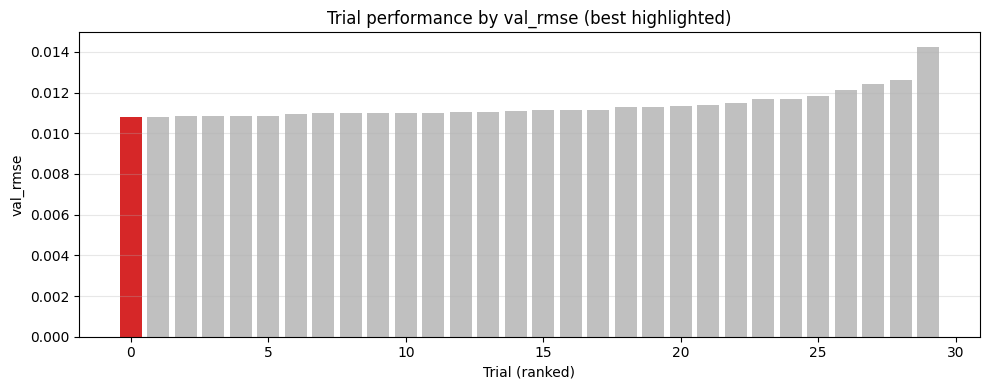

In [8]:
plotting.plot_trial_performance(results_df, metric='val_rmse', mode='min')
plt.show()


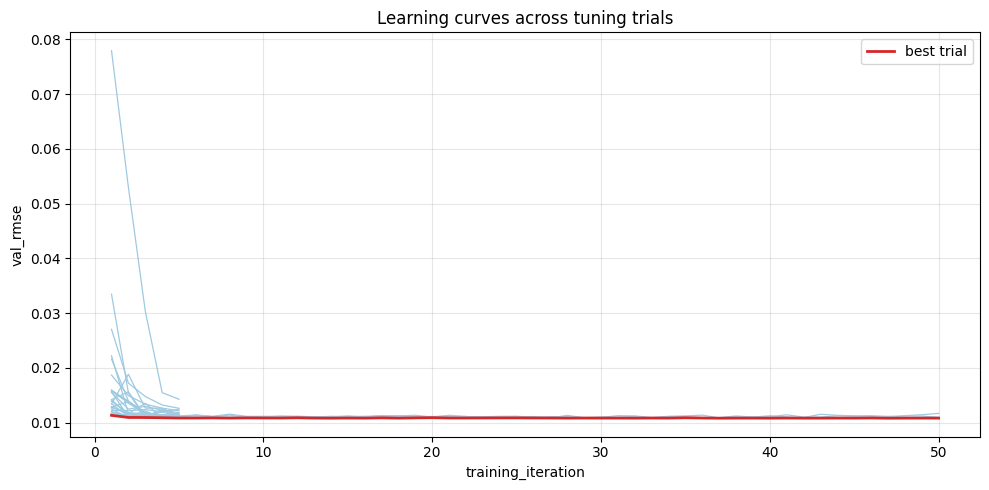

In [9]:
curves = [r.metrics_dataframe for r in results]
final_vals = [
    c['val_rmse'].iloc[-1] if 'val_rmse' in c else np.inf for c in curves
]
best_index = int(np.argmin(final_vals))

plotting.plot_learning_curves(curves, metric='val_rmse', best_index=best_index)
plt.show()


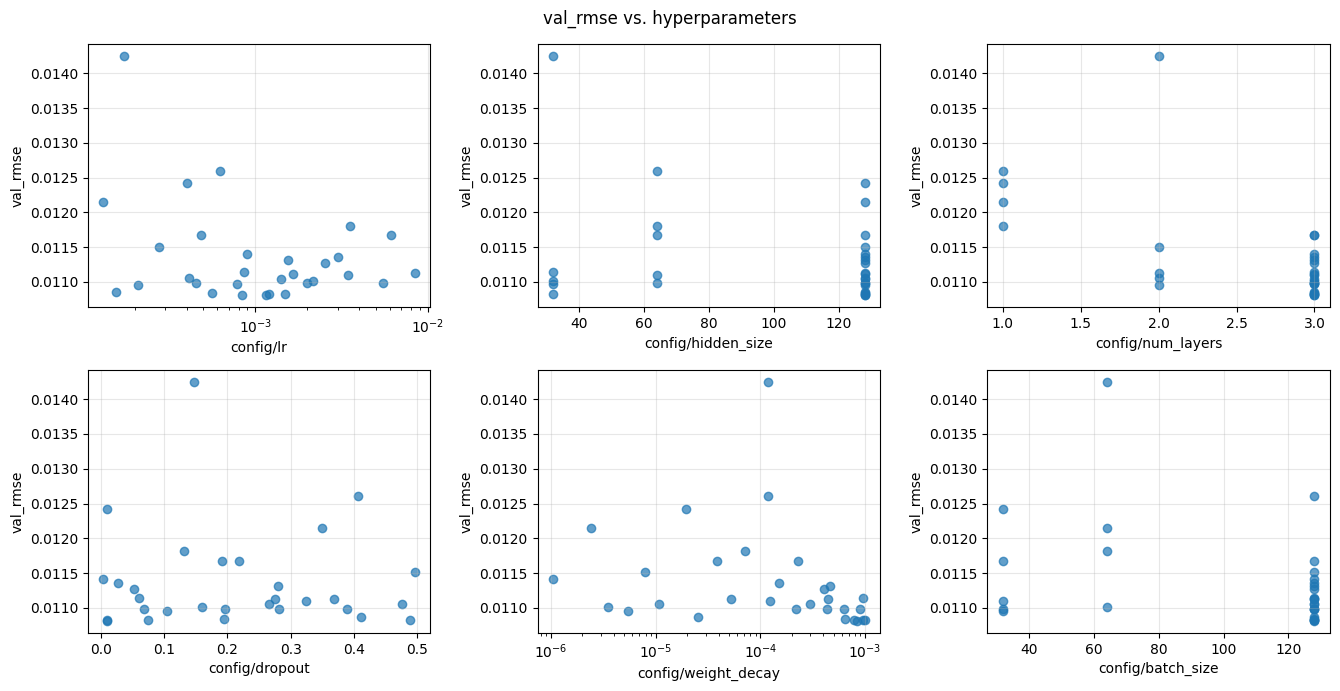

In [10]:
params = [
    f'config/{p}'
    for p in ['lr', 'hidden_size', 'num_layers', 'dropout',
              'weight_decay', 'batch_size']
]
plotting.plot_hyperparameter_effects(results_df, params, metric='val_rmse')
plt.show()


## 5. Final evaluation on the held-out test set

Retrain the best configuration on **all** development data, then score the untouched test period — reporting RMSE and directional (up/down) accuracy.


In [11]:
res = evaluate_on_test(
    best.config,
    X_dev,
    y_dev,
    X_test,
    y_test,
    model_cls=RNNForecaster,
    max_epochs=tune_kwargs['max_epochs'],
    scaler_factory=StandardScaler,
)

print(f"Test RMSE:                 {res['test_rmse']:.5f}")
print(f"Test directional accuracy: {res['test_directional_accuracy']:.3f}")


Test RMSE:                 0.00966
Test directional accuracy: 0.445


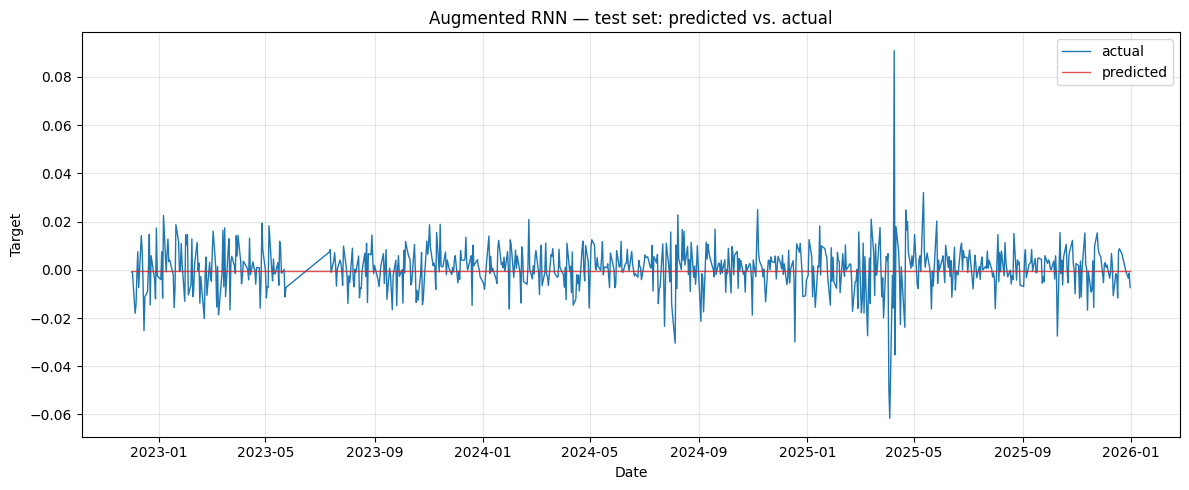

In [12]:
plotting.plot_predictions_vs_actual(
    res['targets'], res['predictions'], index=test_dates,
    title='Augmented RNN — test set: predicted vs. actual',
)
plt.show()


## 6. Save the run to the Shared Drive

Colab sessions are ephemeral and a tuning run is expensive, so everything needed to reuse or audit this run is written to one timestamped folder under `DRIVE_MODELS_PATH`: the model weights and the architecture args needed to rebuild them, the fitted scaler (required for correct inference later), the winning config, the full tuning history, the frozen test predictions, and provenance (dataset, split, seed, git commit).

Saving as `'augmented'` (vs. Stage 03's `'baseline'`) means **Stage 05 can load both runs and compare them head-to-head without retraining anything**.


In [13]:
run_dir = artifacts.save_run(
    'augmented',
    res['model'],
    best.config,
    metrics={
        'test_rmse': res['test_rmse'],
        'test_directional_accuracy': res['test_directional_accuracy'],
        'best_val_rmse': best.metrics['val_rmse'],
    },
    scaler=res['scaler'],
    trials=results_df,
    learning_curves=curves,
    predictions=res['predictions'],
    targets=res['targets'],
    dates=test_dates,
    train_loss_history=res['train_loss_history'],
    extra_metadata={
        'dataset_file': WINDOW_FILE,
        'window_shape': list(X.shape),
        'num_features': int(X.shape[-1]),
        'horizon': int(y.shape[-1]),
        'n_dev': int(len(X_dev)),
        'n_test': int(len(X_test)),
        'test_frac': TEST_FRAC,
        'n_folds': tune_kwargs['n_folds'],
        'num_samples': tune_kwargs['num_samples'],
        'max_epochs': tune_kwargs['max_epochs'],
        'scaler': 'StandardScaler',
        'smoke_test': SMOKE_TEST,
    },
)

print('Saved run ->', run_dir)
for item in sorted(os.listdir(run_dir)):
    print('  ', item)


Saved run -> /content/drive/Shareddrives/COMP 653 - Final Project/saved_models/augmented_20260814_202532
   learning_curves.csv
   manifest.json
   model.pt
   scaler.joblib
   test_predictions.csv
   tuning_trials.csv


In [14]:
# Reload from the Drive and confirm the saved weights reproduce the metrics.
loaded = artifacts.load_run(artifacts.find_latest_run('augmented'))

x_test_scaled = loaded['scaler'].transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)
with torch.no_grad():
    reloaded_preds = loaded['model'](
        torch.as_tensor(x_test_scaled, dtype=torch.float32)
    ).numpy()

print('max |reloaded - original| prediction diff:',
      float(np.abs(reloaded_preds - res['predictions']).max()))
print('manifest metrics:', loaded['manifest']['metrics'])


max |reloaded - original| prediction diff: 0.0
manifest metrics: {'test_rmse': 0.0096642270516046, 'test_directional_accuracy': 0.444743935309973, 'best_val_rmse': 0.010809581496710505}


## Summary

The **pattern-augmented** `RNNForecaster` has been tuned via walk-forward CV on the same schedule as Stage 03, evaluated on the held-out test period, and the complete run (weights, scaler, config, tuning history, predictions, provenance) saved to the Shared Drive under `'augmented'`.

**Next:** Stage 05 loads both the `'baseline'` and `'augmented'` saved runs and compares them head-to-head -- test RMSE, directional accuracy, and predictions over time -- without retraining either.
